# Problème de l'agriculteur 

Un agriculteur produisant des navets et des courgettes souhaite savoir comment produire un maximum (en poids) de légumes.
Un $m^{2}$ de courgettes donne 4kg et un $m^{2}$ de navets 5kg.
Chaque $m^{2}$ de navets nécessite 1kg de guano, 2kg de compost, et 1kg de marc de café. 
Chaque $m^{2}$ de courgettes nécessite 2kg de guano et 1kg de compost. 
Il dispose de 8kg de guano, 7kg de compost, et 3kg de marc de café.

**Variable de décision:**

$x_{1}$ = parcelle pour les courgettes
$x_{2}$ = parcelle pour les navets

---

| Ressource | Navets | Courgettes| Contraintes |
| --------- | ---------- | --------- | ---------|
| guano | 1 | 2 | 8|
| compost | 2 | 1 | 7 |
| marc de café | 1 | 0 | 3 |
| rendement par $m^{2}$ | 5 | 4 | |

---

**Fonction objectif** : **max f($x_{1}, x_{2}$) = $5x_{1} + 4x_{2}$**

Transformons cette tableau en sous forme d'une équation :
$$\left\{ \begin{array}{c} 1x_{1} + 2x_{2} \leq 8 \\ 2x_{1} + 1x_{2} \leq 7 \\ 1x_{1} + 0x_{2} \leq 3 \\ x_{1} \geq 0, x_{2} \geq 0 \end{array}\right. $$

Sous forme matricielle, on a: **Ax $\leq$ b**

où $A=\left(\begin{array}{cc} 1 & 2 \\ 2 & 1 \\ 1 & 0\end{array}\right), \; b = \left(\begin{array}{c} 8 \\ 7 \\ 3\end{array}\right), x = \left(\begin{array}{c} x_{1} \\ x_{2}\end{array}\right)$

**max f(x) = $c^{t}x$** où $c = \left(\begin{array}{c} 5 \\ 4\end{array}\right)$
$$\left\{\begin{array}{c} Ax \leq b \\ x \geq 0 \end{array}\right.$$

In [11]:
import numpy as np
from scipy.optimize import linprog

# Vecteur de profit (C) : on met des signes moins pour maximiser
# Profit = 5*x1 + 4*x2
c = [-5, -4]

# Matrice des contraintes (A)
A = [[1, 2], 
     [2, 1],
    [1, 0]]

# Vecteur des limites (b)
b = [8, 7, 3]

# Définition des bornes (x1 et x2 doivent être positifs)
x_bounds = (0, None)

# Résolution
res = linprog(c, A_ub=A, b_ub=b, bounds=[x_bounds, x_bounds], method='highs')

# Affichage des résultats
print(f"Statut : {res.message}")
print(f"Solution optimale : x1 = {res.x[0]:.2f}, x2 = {res.x[1]:.2f}")
print(f"Profit maximum : {-res.fun:.2f}")

Statut : Optimization terminated successfully. (HiGHS Status 7: Optimal)
Solution optimale : x1 = 2.00, x2 = 3.00
Profit maximum : 22.00



Génération du graphique...


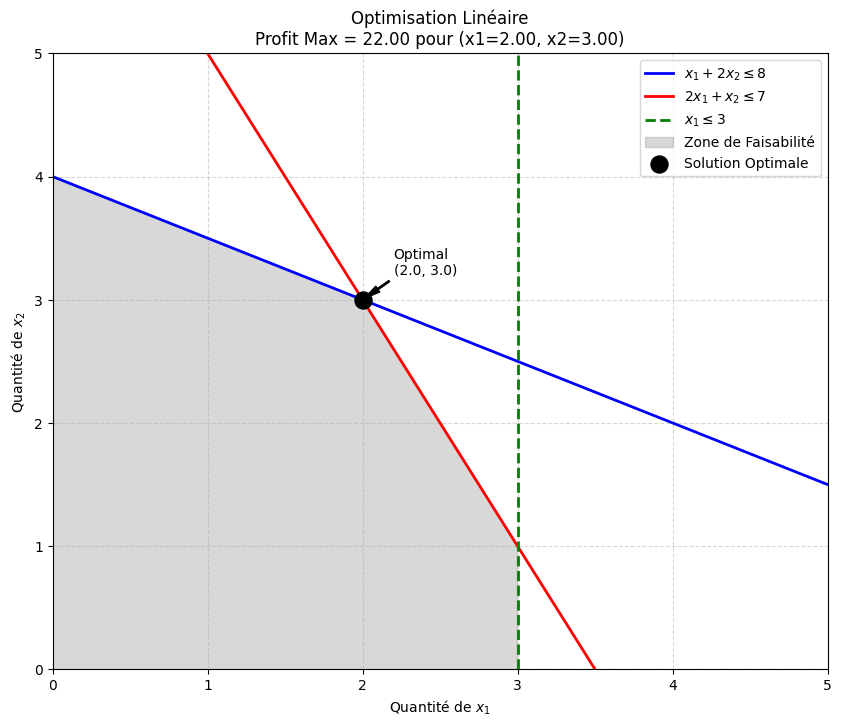

In [12]:
# Définition de l'espace pour x1 (axe horizontal)
# On va un peu au-delà des contraintes pour bien voir (max x1 est 3, max b est 8)
x1_vals = np.linspace(0, 5, 400)

# Définition des fonctions de contraintes pour x2 (axe vertical)
# C1: 1*x1 + 2*x2 <= 8  =>  x2 <= (8 - x1) / 2
def contrainte1(x1):
    return (8 - x1) / 2

# C2: 2*x1 + 1*x2 <= 7  =>  x2 <= 7 - 2*x1
def contrainte2(x1):
    return 7 - 2 * x1

# C3: 1*x1 + 0*x2 <= 3  =>  x1 <= 3 (C'est une ligne verticale, gérée différemment)

# Calcul des valeurs y (x2) pour les tracer
y_c1 = contrainte1(x1_vals)
y_c2 = contrainte2(x1_vals)

# Création de la figure
plt.figure(figsize=(10, 8))
plt.title(f"Optimisation Linéaire\nProfit Max = {profit_opt:.2f} pour (x1={sol_x1:.2f}, x2={sol_x2:.2f})")
plt.xlabel("Quantité de $x_1$")
plt.ylabel("Quantité de $x_2$")

# --- Tracé des lignes de contraintes ---
plt.plot(x1_vals, y_c1, label=r"$x_1 + 2x_2 \leq 8$", color='blue', linewidth=2)
plt.plot(x1_vals, y_c2, label=r"$2x_1 + x_2 \leq 7$", color='red', linewidth=2)
# Pour la contrainte verticale x1 <= 3
plt.axvline(x=3, label=r"$x_1 \leq 3$", color='green', linewidth=2, linestyle='--')

# --- Définition et remplissage de la Zone de Faisabilité ---
# La zone doit être en dessous de C1, en dessous de C2, et à gauche de C3 (x1<=3)
# Et aussi au-dessus des axes (x1>=0, x2>=0)

# 1. Trouver le minimum entre C1 et C2
y_feasible = np.minimum(y_c1, y_c2)

# 2. S'assurer que x2 reste positif
y_feasible = np.maximum(y_feasible, 0)


sol_x1, sol_x2 = res.x

# 3. Appliquer la contrainte verticale x1 <= 3
# On crée un masque : True là où x1 <= 3
mask_x1_lim = x1_vals <= 3

# Remplissage de la zone respectant toutes les contraintes
plt.fill_between(x1_vals[mask_x1_lim], 0, y_feasible[mask_x1_lim], 
                 color='gray', alpha=0.3, label="Zone de Faisabilité")

# --- Marquage du Point Optimal ---
if res.success:
    plt.scatter(sol_x1, sol_x2, color='black', s=150, zorder=5, label="Solution Optimale")
    plt.annotate(f"Optimal\n({sol_x1:.1f}, {sol_x2:.1f})", 
                 (sol_x1, sol_x2), 
                 xytext=(sol_x1 + 0.2, sol_x2 + 0.2),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

# --- Réglages finaux ---
plt.xlim(0, 5) # Limites de l'axe x
plt.ylim(0, 5) # Limites de l'axe y
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

# Affichage
print("\nGénération du graphique...")
plt.show()